In [9]:
#다항 회뒤 예제

In [10]:
# 데이터 생성(문제와 정답)
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

dataset = pd.read_csv('다항회귀_성적.csv')

In [11]:
# 독립변수, 종속변수 분리(문제와 정답을 분리)
X = dataset.iloc[: , :-1] # 독립변수
y = dataset.iloc[: , -1] # 종속변수

In [12]:
# 훈련데이터, 테스트 데이터 분리(기출문제, 모의고사를 분리)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=20)

In [13]:
# 다항식 변환 : 다항식을 표현하기 위해 직선을 이용 => 차수에 맞데 데이터를 늘림
# 다항 차수 설정(2차항까지). b는 포함 안함
poly = PolynomialFeatures(degree=2, include_bias=False)

# 변환 실행
X_train_poly = poly.fit_transform(X_train)

In [14]:
# 학습
reg = LinearRegression()
reg.fit(X_train_poly, y_train)
# 테스트 데이터도 똑같은 차수로 변환
X_test_poly = poly.transform(X_test)

In [15]:
# 성능 확인(테스트 데이터를 이용)
train_score = reg.score(X_train_poly, y_train)
test_score = reg.score(X_test_poly, y_test)

print(f"훈련 세트 점수: {train_score:.2f}")
print(f"테스트 세트 점수: {test_score:.2f}")

훈련 세트 점수: 0.97
테스트 세트 점수: 0.98


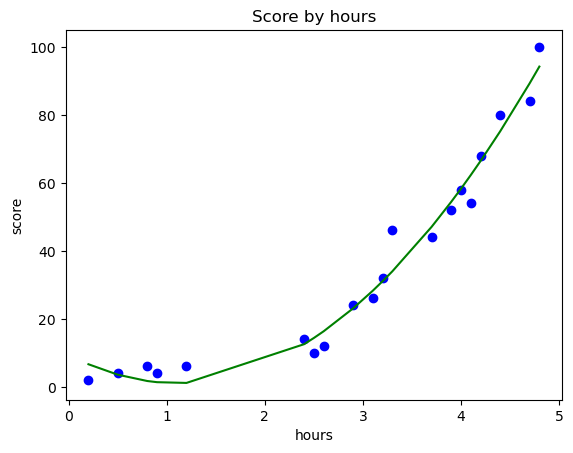

In [16]:
# 데이터 시각화
# 시각화 할 때 곡선처럼 보이게 하기 위해 데이터들을 일정 간격으로 나눔
x_range = np.arange(X.min().item(), X.max().item(), 0.1) # x의 최소값에서 최대값까지의 범위를 0.1 단위로 잘라서 데이터를 생성
x_range = x_range.reshape(-1, 1) # row 개수는 자동으로 계산, column 개수는 1개

plt.scatter(X, y, color='blue')
plt.plot(X, reg.predict(poly.transform(X)), color='green')
plt.title('Score by hours')
plt.xlabel('hours')
plt.ylabel('score')
plt.show()